<a href="https://colab.research.google.com/github/sosojosafars/IA_On_26-1/blob/main/IA_On_Aula02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Implementando um Perceptron em Python

print(" ------------ PARTE 2 ------------ ")

# 2.1 Preparação: Importar Bibliotecas
# Importar bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt

# Configurar visualizações
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Fixar seed para reprodutibilidade
np.random.seed(42)

print("✅ Bibliotecas carregadas com sucesso!")

# 2.2 Implementação da Classe Perceptron

class Perceptron:
    def __init__(self, learning_rate=0.1, n_iterations=100):

        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None # Pesos (w) - serão inicializados no treino
        self.bias = None # Bias (b) - será inicializado no treino
        self.errors_history = [] # Histórico de erros por época (para análise)

    def step_function(self, z):

        return np.where(z >= 0, 1, 0)

    def predict(self, X):

        # Produto escalar: soma ponderada das entradas
        linear_output = np.dot(X, self.weights) + self.bias

        # Aplicar função de ativação
        predictions = self.step_function(linear_output)
        return predictions

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Passo 1: Inicializar pesos e bias com zeros

        # Poderíamos usar valores aleatórios, mas zeros funcionam bem aqui
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Imprimir estado inicial
        print(f"🎯 Iniciando treinamento...")
        print(f" Pesos iniciais: {self.weights}")
        print(f" Bias inicial: {self.bias}")
        print(f" Taxa de aprendizado: {self.learning_rate}")
        print(f" Número de amostras: {n_samples}")
        print("-" * 50)

        # Passo 2: Loop de treinamento (épocas)
        for epoch in range(self.n_iterations):
            errors = 0 # Contador de erros nesta época

            # Para cada exemplo de treinamento
            for idx, x_i in enumerate(X):
                # Fazer previsão para este exemplo
                # Reshape necessário pois predict espera array 2D
                prediction = self.predict(x_i.reshape(1, -1))[0]

                # Calcular erro
                error = y[idx] - prediction

                # Atualizar pesos se houve erro
                if error != 0:
                    # Regra de atualização do perceptron
                    update = self.learning_rate * error
                    self.weights += update * x_i
                    self.bias += update
                    errors += 1

            # Armazenar número de erros desta época
            self.errors_history.append(errors)

            # Mostrar progresso a cada 10 épocas
            if (epoch + 1) % 10 == 0:
                print(f"Época {epoch + 1:3d} | Erros: {errors:2d} | "
                      f"Pesos: {self.weights} | Bias: {self.bias:.4f}")

            # Critério de parada: se não houver erros, convergiu
            if errors == 0:
                print(f"\n✅ Convergência alcançada na época {epoch + 1}!")
                print(f" Pesos finais: {self.weights}")
                print(f" Bias final: {self.bias:.4f}")
                break

        # Se saiu do loop sem convergir
        if errors > 0:
            print(f"\n⚠ Treinamento finalizado sem convergência completa")
            print(f" Ainda havia {errors} erros na última época")
        return self

# Teste rápido da classe
print("\n" + "="*50)
print("CLASSE PERCEPTRON IMPLEMENTADA COM SUCESSO!")
print("="*50)

 ------------ PARTE 2 ------------ 
✅ Bibliotecas carregadas com sucesso!

CLASSE PERCEPTRON IMPLEMENTADA COM SUCESSO!


 ------------ PARTE 3 ------------ 

EXPERIMENTO 1: PORTA LÓGICA AND

📊 Dataset AND:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[0 0 0 1]

------------------------------------------------------------
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 4!
 Pesos finais: [0.2 0.1]
 Bias final: -0.2000

------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------

🎯 Comparação: Esperado vs Previsto
----------------------------------------
Entrada: [0 0] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [0 1] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [1 0] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [1 1] | Esperado: 1 | Previsto: 1 | ✅ CORRETO

🎯 Acurácia: 100.00%


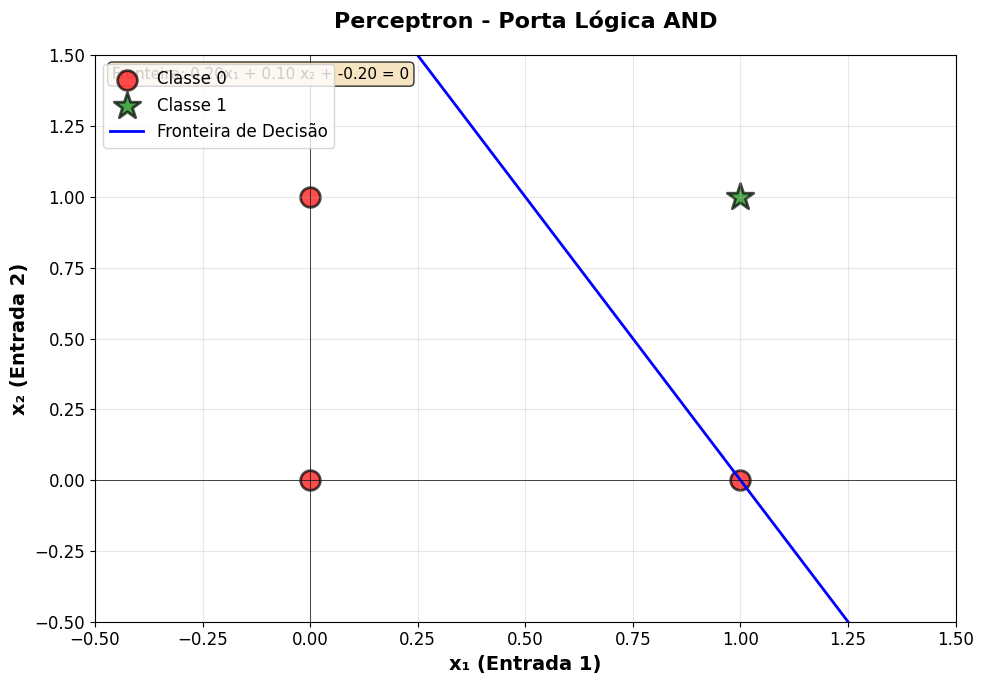


📊 Interpretação do Gráfico:
------------------------------------------------------------
• A linha azul é a FRONTEIRA DE DECISÃO
• Tudo acima/à direita da linha: perceptron prevê 1
• Tudo abaixo/à esquerda da linha: perceptron prevê 0
• Círculos vermelhos: classe 0 (AND retorna 0)
• Estrelas verdes: classe 1 (AND retorna 1)

✅ Note que a linha separa perfeitamente as duas classes!


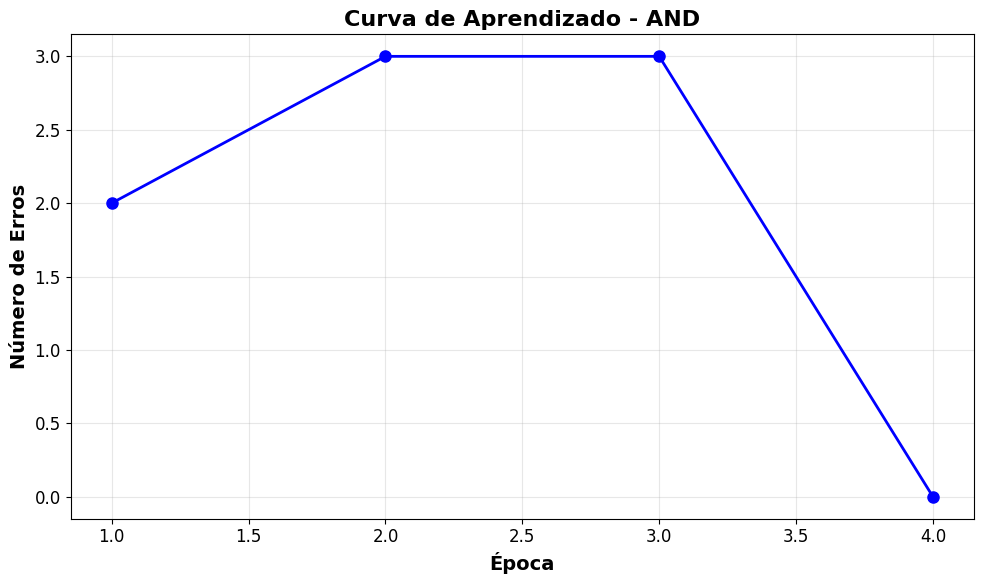


📊 Análise da Curva de Aprendizado:
------------------------------------------------------------
• Número total de épocas: 4
• Erros na época 1: 2
• Erros na última época: 0
• Convergência: SIM ✅

💡 O que isso significa:
 O perceptron começou errando algumas previsões,
 mas aprendeu rapidamente e chegou a zero erros.
 Isso acontece porque AND é linearmente separável!


In [ ]:
print(" ------------ PARTE 3 ------------ ")

print("\n" + "="*60)
print("EXPERIMENTO 1: PORTA LÓGICA AND")
print("="*60)

# Criar dataset para AND
X_and = np.array([
[0, 0], # Entrada 1
[0, 1], # Entrada 2
[1, 0], # Entrada 3
[1, 1]  # Entrada 4
])

y_and = np.array([0, 0, 0, 1]) # Saídas esperadas

print("\n📊 Dataset AND:")
print("Entradas (X):")
print(X_and)
print("\nSaídas esperadas (y):")
print(y_and)
print("\n" + "-"*60)

# Criar e treinar o perceptron
perceptron_and = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_and.fit(X_and, y_and)

print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)

# Fazer previsões
predictions_and = perceptron_and.predict(X_and)

print("\n🎯 Comparação: Esperado vs Previsto")
print("-"*40)
for i in range(len(X_and)):
  print(f"Entrada: {X_and[i]} | Esperado: {y_and[i]} | "
        f"Previsto: {predictions_and[i]} | "
        f"{'✅ CORRETO' if y_and[i] == predictions_and[i] else '❌ ERRADO'}")

# Calcular acurácia
accuracy_and = np.mean(predictions_and == y_and) * 100
print(f"\n🎯 Acurácia: {accuracy_and:.2f}%")

def plot_decision_boundary(X, y, perceptron, title):

# Configurar o gráfico
  plt.figure(figsize=(10, 7))

# Plotar pontos de dados
# Classe 0 (círculos vermelhos)
  plt.scatter(X[y == 0, 0], X[y == 0, 1],
  color='red', marker='o', s=200,
  edgecolors='black', linewidths=2,
  label='Classe 0', alpha=0.7)

# Classe 1 (estrelas verdes)
  plt.scatter(X[y == 1, 0], X[y == 1, 1],
  color='green', marker='*', s=400,
  edgecolors='black', linewidths=2,
  label='Classe 1', alpha=0.7)

# Calcular e plotar fronteira de decisão
# A fronteira é definida por: w₁x₁ + w₂x₂ + b = 0
# Resolvendo para x₂: x₂ = -(w₁x₁ + b) / w₂

# Criar pontos x₁ de -0.5 a 1.5 (margem ao redor dos dados)
  x1_boundary = np.linspace(-0.5, 1.5, 100)

# Calcular x₂ correspondentes
# Evitar divisão por zero

  if perceptron.weights[1] != 0:
    x2_boundary = -(perceptron.weights[0] * x1_boundary + perceptron.bias) / perceptron.weights[1]
    plt.plot(x1_boundary, x2_boundary, 'b-', linewidth=2,
      label='Fronteira de Decisão')

# Configurações do gráfico
  plt.xlim(-0.5, 1.5)
  plt.ylim(-0.5, 1.5)
  plt.xlabel('x₁ (Entrada 1)', fontsize=14, fontweight='bold')
  plt.ylabel('x₂ (Entrada 2)', fontsize=14, fontweight='bold')
  plt.title(title, fontsize=16, fontweight='bold', pad=20)
  plt.legend(loc='upper left', fontsize=12)
  plt.grid(True, alpha=0.3)
  plt.axhline(y=0, color='k', linewidth=0.5)
  plt.axvline(x=0, color='k', linewidth=0.5)

# Adicionar anotações com os pesos
  equation = f'Fronteira: {perceptron.weights[0]:.2f}x₁ + {perceptron.weights[1]:.2f} x₂ + {perceptron.bias:.2f} = 0'
  plt.text(0.02, 0.98, equation, transform=plt.gca().transAxes,
  fontsize=11, verticalalignment='top',
  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
  plt.tight_layout()
  plt.show()

# Plotar resultado para AND
plot_decision_boundary(X_and, y_and, perceptron_and,
  'Perceptron - Porta Lógica AND')
print("\n📊 Interpretação do Gráfico:")
print("-" * 60)
print("• A linha azul é a FRONTEIRA DE DECISÃO")
print("• Tudo acima/à direita da linha: perceptron prevê 1")
print("• Tudo abaixo/à esquerda da linha: perceptron prevê 0")
print("• Círculos vermelhos: classe 0 (AND retorna 0)")
print("• Estrelas verdes: classe 1 (AND retorna 1)")
print("\n✅ Note que a linha separa perfeitamente as duas classes!")

# Plotar evolução dos erros
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron_and.errors_history) + 1),
  perceptron_and.errors_history,
  marker='o', linewidth=2, markersize=8, color='blue')
plt.xlabel('Época', fontsize=14, fontweight='bold')
plt.ylabel('Número de Erros', fontsize=14, fontweight='bold')
plt.title('Curva de Aprendizado - AND', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Análise da Curva de Aprendizado:")
print("-" * 60)
print(f"• Número total de épocas: {len(perceptron_and.errors_history)}")
print(f"• Erros na época 1: {perceptron_and.errors_history[0]}")
print(f"• Erros na última época: {perceptron_and.errors_history[-1]}")
print(f"• Convergência: {'SIM ✅' if perceptron_and.errors_history[-1] == 0
else 'NÃO ❌'}")
print("\n💡 O que isso significa:")
print(" O perceptron começou errando algumas previsões,")
print(" mas aprendeu rapidamente e chegou a zero erros.")
print(" Isso acontece porque AND é linearmente separável!")



In [21]:
print(" ------------ PARTE 4 ------------ ")

print("\n" + "="*60)
print("EXPERIMENTO 2: PORTA LÓGICA OR")
print("="*60)

# Criar dataset para OR
X_or = np.array([
[0, 0],
[0, 1],
[1, 0],
[1, 1]
])

y_or = np.array([0, 1, 1, 1]) # Saídas esperadas

print("\n📊 Dataset OR:")
print("Entradas (X):")
print(X_or)
print("\nSaídas esperadas (y):")
print(y_or)
print("\n" + "-"*60)

# Criar e treinar o perceptron
perceptron_or = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_or.fit(X_or, y_or)
print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)

# Fazer previsões
predictions_or = perceptron_or.predict(X_or)

print("\n🎯 Comparação: Esperado vs Previsto")
print("-"*40)
for i in range(len(X_or)):
  print(f"Entrada: {X_or[i]} | Esperado: {y_or[i]} | "
        f"Previsto: {predictions_or[i]} | "
        f"{'✅ CORRETO' if y_or[i] == predictions_or[i] else '❌ ERRADO'}")

# Calcular acurácia
accuracy_or = np.mean(predictions_or == y_or) * 100
print(f"\n🎯 Acurácia: {accuracy_or:.2f}%")

# Visualizar
plot_decision_boundary(X_or, y_or, perceptron_or,
'Perceptron - Porta Lógica OR')

print("\n" + "="*60)
print("COMPARAÇÃO: AND vs OR")
print("="*60)
print("\n📊 Pesos Finais:")
print("-" * 40)
print(f"AND - Peso 1: {perceptron_and.weights[0]:.4f}")
print(f"AND - Peso 2: {perceptron_and.weights[1]:.4f}")
print(f"AND - Bias: {perceptron_and.bias:.4f}")
print()
print(f"OR - Peso 1: {perceptron_or.weights[0]:.4f}")
print(f"OR - Peso 2: {perceptron_or.weights[1]:.4f}")
print(f"OR - Bias: {perceptron_or.bias:.4f}")
print("\n💡 Interpretação:")
print("-" * 60)
print("• Para AND: pesos maiores e bias mais negativo")
print(" → Precisa de MAIS evidência para ativar (ambas entradas)")
print()
print("• Para OR: pesos menores e bias menos negativo")
print(" → Precisa de MENOS evidência para ativar (qualquer entrada)")
print()
print("• Ambos convergem rapidamente porque são linearmente separáveis!")

 ------------ PARTE 4 ------------ 

EXPERIMENTO 2: PORTA LÓGICA OR

📊 Dataset OR:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[0 1 1 1]

------------------------------------------------------------
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 4!
 Pesos finais: [0.1 0.1]
 Bias final: -0.1000

------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------

🎯 Comparação: Esperado vs Previsto
----------------------------------------
Entrada: [0 0] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [0 1] | Esperado: 1 | Previsto: 1 | ✅ CORRETO
Entrada: [1 0] | Esperado: 1 | Previsto: 1 | ✅ CORRETO
Entrada: [1 1] | Esperado: 1 | Previsto: 1 | ✅ CORRETO

🎯 Acurácia: 100.00%


NameError: name 'plot_decision_boundary' is not defined

 ------------ PARTE 5 ------------ 

EXPERIMENTO 3: PORTA LÓGICA XOR

📊 Dataset XOR:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[0 1 1 0]

⚠ ATENÇÃO: XOR é NÃO linearmente separável!
 O perceptron NÃO deve conseguir aprender este padrão.

------------------------------------------------------------
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------
Época  10 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  20 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  30 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  40 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  50 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  60 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  70 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  80 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  90 | Erros:  4 | Pesos: [-0.1  0. ] |

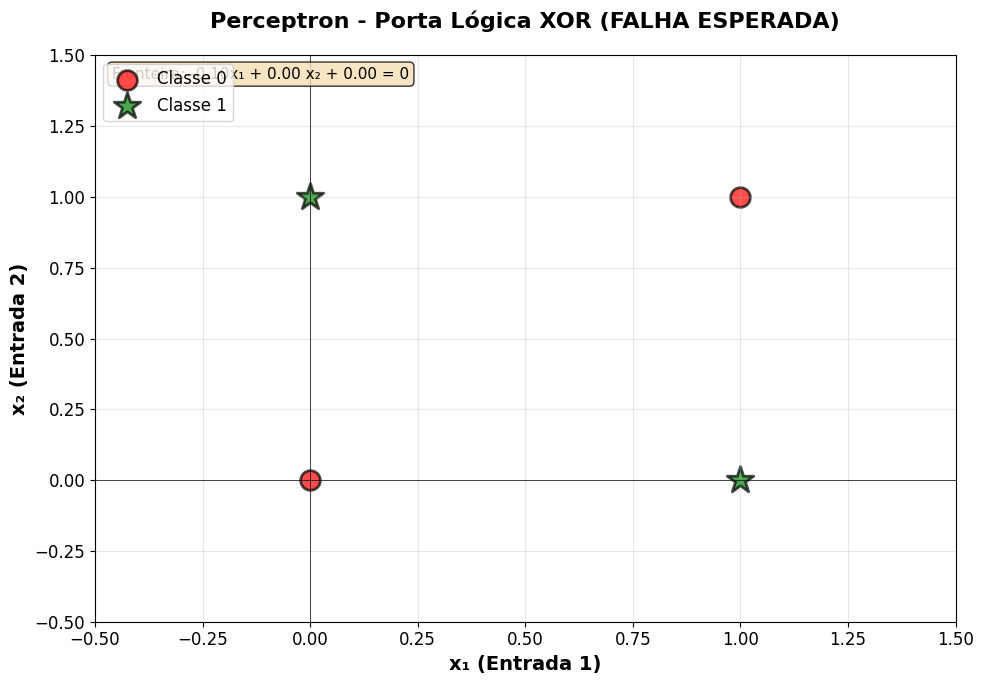


POR QUE O PERCEPTRON FALHA NO XOR?

🔍 Análise Geométrica:
------------------------------------------------------------
1. O perceptron só consegue desenhar LINHAS RETAS
2. XOR precisa de uma separação em FORMATO DE CRUZ ou CURVA
3. Matematicamente: XOR é NÃO linearmente separável

Visualizando:

 x₂
 1│ [0] [1]
 │
 0│ [0] [1]
 └────────────── x₁
 0 1

Impossível separar com uma linha reta!

💡 Solução Histórica:
 • 1969: Minsky & Papert publicam 'Perceptrons'
 • Provam matematicamente a limitação
 • Causa o primeiro 'inverno da IA'
 • Solução: Redes Neurais Multicamadas (1986)


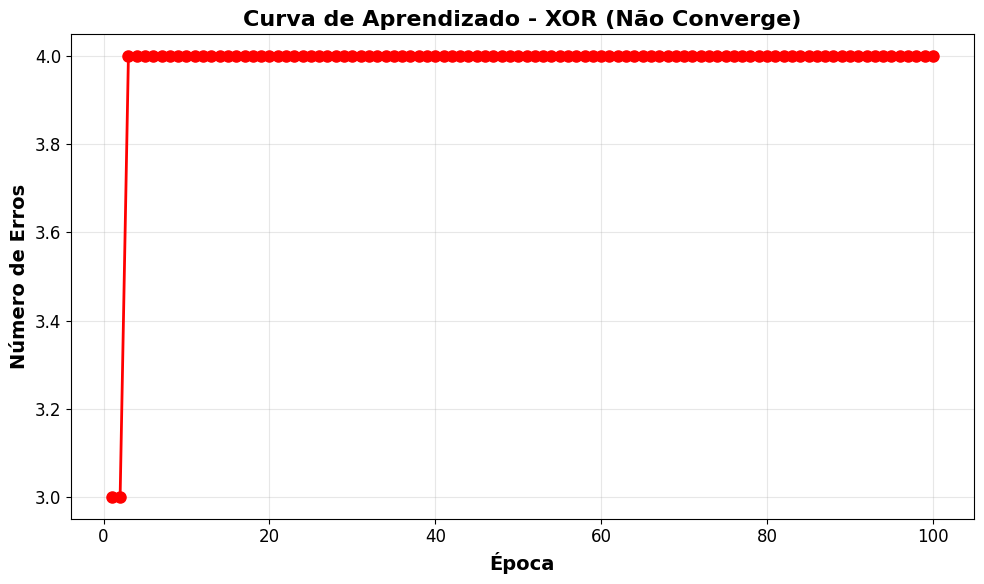


📊 Análise da Curva:
------------------------------------------------------------
• Note que o número de erros NÃO chega a zero
• O perceptron fica 'preso' tentando aprender
• Não há configuração de pesos que resolva XOR com uma linha
• Este foi um resultado CRUCIAL na história da IA


In [ ]:
print(" ------------ PARTE 5 ------------ ")

print("\n" + "="*60)
print("EXPERIMENTO 3: PORTA LÓGICA XOR")
print("="*60)
# Criar dataset para XOR
X_xor = np.array([
  [0, 0],
  [0, 1],
  [1, 0],
  [1, 1]
])

y_xor = np.array([0, 1, 1, 0]) # Saídas esperadas

print("\n📊 Dataset XOR:")
print("Entradas (X):")
print(X_xor)
print("\nSaídas esperadas (y):")
print(y_xor)
print("\n⚠ ATENÇÃO: XOR é NÃO linearmente separável!")
print(" O perceptron NÃO deve conseguir aprender este padrão.")
print("\n" + "-"*60)

# Criar e treinar o perceptron
perceptron_xor = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_xor.fit(X_xor, y_xor)

print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)

# Fazer previsões
predictions_xor = perceptron_xor.predict(X_xor)

print("\n🎯 Comparação: Esperado vs Previsto")
print("-"*40)
for i in range(len(X_xor)):
  print(f"Entrada: {X_xor[i]} | Esperado: {y_xor[i]} | "
        f"Previsto: {predictions_xor[i]} | "
        f"{'✅ CORRETO' if y_xor[i] == predictions_xor[i] else '❌ERRADO'}")

# Calcular acurácia
accuracy_xor = np.mean(predictions_xor == y_xor) * 100
print(f"\n🎯 Acurácia: {accuracy_xor:.2f}%")

if accuracy_xor < 100:
  print("\n⚠ FALHA ESPERADA!")
  print(" O perceptron não conseguiu aprender XOR perfeitamente.")

# Visualizar
plot_decision_boundary(X_xor, y_xor, perceptron_xor,
'Perceptron - Porta Lógica XOR (FALHA ESPERADA)')

print("\n" + "="*60)
print("POR QUE O PERCEPTRON FALHA NO XOR?")
print("="*60)
print("\n🔍 Análise Geométrica:")
print("-" * 60)
print("1. O perceptron só consegue desenhar LINHAS RETAS")
print("2. XOR precisa de uma separação em FORMATO DE CRUZ ou CURVA")
print("3. Matematicamente: XOR é NÃO linearmente separável")
print()
print("Visualizando:")
print()
print(" x₂")
print(" 1│ [0] [1]")
print(" │")
print(" 0│ [0] [1]")
print(" └────────────── x₁")
print(" 0 1")
print()
print("Impossível separar com uma linha reta!")
print()
print("💡 Solução Histórica:")
print(" • 1969: Minsky & Papert publicam 'Perceptrons'")
print(" • Provam matematicamente a limitação")
print(" • Causa o primeiro 'inverno da IA'")
print(" • Solução: Redes Neurais Multicamadas (1986)")

# Plotar curva de aprendizado do XOR
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron_xor.errors_history) + 1),
  perceptron_xor.errors_history,
  marker='o', linewidth=2, markersize=8, color='red')
plt.xlabel('Época', fontsize=14, fontweight='bold')
plt.ylabel('Número de Erros', fontsize=14, fontweight='bold')
plt.title('Curva de Aprendizado - XOR (Não Converge)',
  fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📊 Análise da Curva:")
print("-" * 60)
print("• Note que o número de erros NÃO chega a zero")
print("• O perceptron fica 'preso' tentando aprender")
print("• Não há configuração de pesos que resolva XOR com uma linha")
print("• Este foi um resultado CRUCIAL na história da IA")

 ------------ PARTE 6 ------------ 

EXPERIMENTO 4: IMPACTO DA TAXA DE APRENDIZADO

Taxa de Aprendizado: 0.01
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.01
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 6!
 Pesos finais: [0.02 0.01]
 Bias final: -0.0300

Taxa de Aprendizado: 0.1
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 4!
 Pesos finais: [0.2 0.1]
 Bias final: -0.2000

Taxa de Aprendizado: 1.0
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 1.0
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 6!
 Pesos finais: [2. 1.]
 Bias final: -3.0000


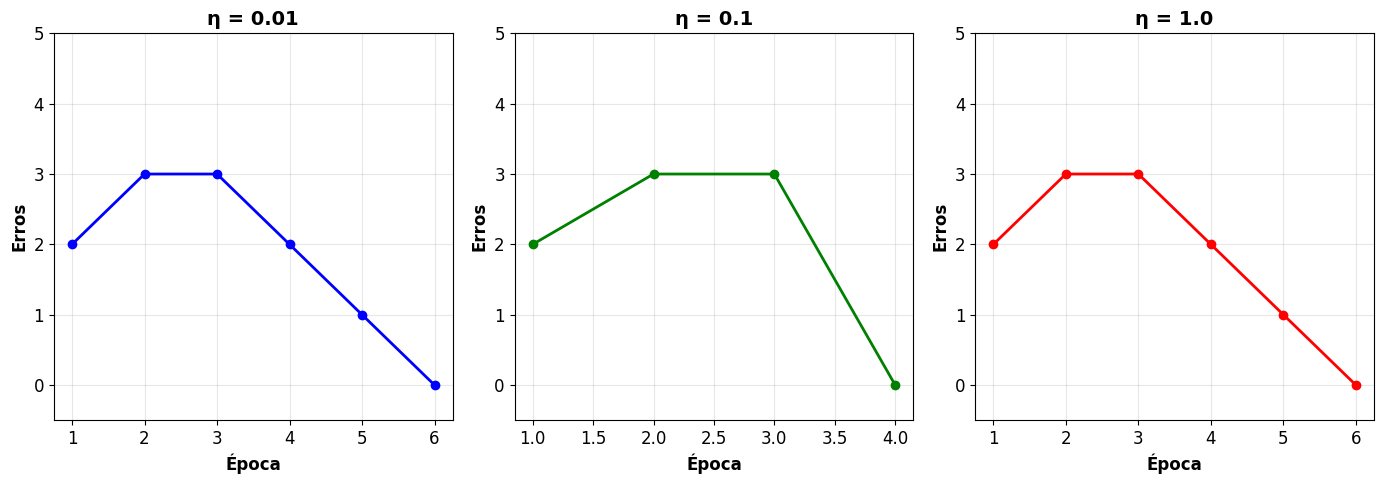


ANÁLISE DOS RESULTADOS

🐌 Taxa Baixa (η = 0.01):
------------------------------------------------------------
• Convergência LENTA
• Passos muito pequenos
• Seguro, mas ineficiente
• Use quando: dados ruidosos ou instabilidade

⚖ Taxa Moderada (η = 0.1):
------------------------------------------------------------
• EQUILÍBRIO ideal
• Convergência rápida e estável
• Valor PADRÃO recomendado
• Use quando: situação típica

🚀 Taxa Alta (η = 1.0):
------------------------------------------------------------
• Convergência muito rápida OU instabilidade
• Passos grandes podem 'pular' a solução
• Pode oscilar sem convergir em problemas complexos
• Use quando: problema simples e quer velocidade

💡 Regra Prática:
------------------------------------------------------------
• Comece com η = 0.1 (valor padrão)
• Se não convergir: reduza (ex: 0.01)
• Se convergir muito devagar: aumente (ex: 0.5)
• Problemas difíceis: taxas menores (0.001 - 0.1)
• Problemas simples: taxas maiores (0.1 - 1.0)

TABE

In [ ]:
print(" ------------ PARTE 6 ------------ ")

print("\n" + "="*60)
print("EXPERIMENTO 4: IMPACTO DA TAXA DE APRENDIZADO")
print("="*60)

# Testar diferentes taxas de aprendizado
learning_rates = [0.01, 0.1, 1.0]
colors = ['blue', 'green', 'red']

plt.figure(figsize=(14, 5))

for idx, lr in enumerate(learning_rates):
  print(f"\n{'='*60}")
  print(f"Taxa de Aprendizado: {lr}")
  print(f"{'='*60}")

  # Treinar perceptron com esta taxa
  perceptron_lr = Perceptron(learning_rate=lr, n_iterations=100)
  perceptron_lr.fit(X_and, y_and)

  # Plotar curva de aprendizado
  plt.subplot(1, 3, idx + 1)
  plt.plot(range(1, len(perceptron_lr.errors_history) + 1),
    perceptron_lr.errors_history,
    marker='o', linewidth=2, markersize=6, color=colors[idx])
  plt.xlabel('Época', fontsize=12, fontweight='bold')
  plt.ylabel('Erros', fontsize=12, fontweight='bold')
  plt.title(f'η = {lr}', fontsize=14, fontweight='bold')
  plt.grid(True, alpha=0.3)
  plt.ylim(-0.5, 5)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANÁLISE DOS RESULTADOS")
print("="*60)

print("\n🐌 Taxa Baixa (η = 0.01):")
print("-" * 60)
print("• Convergência LENTA")
print("• Passos muito pequenos")
print("• Seguro, mas ineficiente")
print("• Use quando: dados ruidosos ou instabilidade")

print("\n⚖ Taxa Moderada (η = 0.1):")
print("-" * 60)
print("• EQUILÍBRIO ideal")
print("• Convergência rápida e estável")
print("• Valor PADRÃO recomendado")
print("• Use quando: situação típica")

print("\n🚀 Taxa Alta (η = 1.0):")
print("-" * 60)
print("• Convergência muito rápida OU instabilidade")
print("• Passos grandes podem 'pular' a solução")
print("• Pode oscilar sem convergir em problemas complexos")
print("• Use quando: problema simples e quer velocidade")

print("\n💡 Regra Prática:")
print("-" * 60)
print("• Comece com η = 0.1 (valor padrão)")
print("• Se não convergir: reduza (ex: 0.01)")
print("• Se convergir muito devagar: aumente (ex: 0.5)")
print("• Problemas difíceis: taxas menores (0.001 - 0.1)")
print("• Problemas simples: taxas maiores (0.1 - 1.0)")

# Criar tabela comparativa
print("\n" + "="*60)
print("TABELA COMPARATIVA: IMPACTO DA TAXA DE APRENDIZADO")
print("="*60)

results = []

for lr in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:
  perceptron_test = Perceptron(learning_rate=lr, n_iterations=100)
  perceptron_test.fit(X_and, y_and)

  results.append({
    'Taxa': lr,
    'Épocas': len(perceptron_test.errors_history),
    'Convergiu': perceptron_test.errors_history[-1] == 0,
    'Erros_Finais': perceptron_test.errors_history[-1]
  })

print("\n{:<10} {:<10} {:<12} {:<15}".format(
"Taxa (η)", "Épocas", "Convergiu?", "Erros Finais"
))
print("-" * 60)

for r in results:
  print("{:<10} {:<10} {:<12} {:<15}".format(
    r['Taxa'],
    r['Épocas'],
    "✅ Sim" if r['Convergiu'] else "❌ Não",
    r['Erros_Finais']
  ))

print("\n" + "="*60)

In [ ]:
print(" ------------ PARTE 7 ------------ ")

print("\n" + "="*60)
print("DO PERCEPTRON AO DEEP LEARNING")
print("="*60)

print("""
📜 LINHA DO TEMPO E EVOLUÇÃO:
1943 - McCulloch & Pitts
│ Primeiro modelo matemático de neurônio
│
1958 - Rosenblatt
│ PERCEPTRON (o que implementamos hoje!)
│ ✅ Aprende padrões lineares
│ ❌ Não resolve XOR
│
1969 - Minsky & Papert
│ Livro "Perceptrons" → Primeiro Inverno da IA
│ Provam limitações matemáticas
│
1986 - Rumelhart, Hinton & Williams
│ BACKPROPAGATION + Redes Multicamadas
│ ✅ Resolve XOR com camada oculta
│ ✅ Funções não-lineares
│
2012 - Krizhevsky (AlexNet)
│ Deep Learning vence ImageNet
│ Revolução da IA moderna
│
2017-2024 - Era Transformer
│ GPT, BERT, ChatGPT, Gemini
│ Bilhões de parâmetros
│ Mas o PRINCÍPIO é o mesmo! ⚡
""")
print("🧠 Como o Perceptron se Conecta com Redes Modernas:")
print("-" * 60)
print()
print("1. NEURÔNIO BÁSICO (Perceptron):")
print("   ŷ = f(w·x + b)")
print()
print("2. REDE NEURAL MULTICAMADAS:")
print(" • Empilhar múltiplos perceptrons")
print(" • Adicionar camadas ocultas")
print(" • Resolver problemas não-lineares (XOR!)")
print()
print("3. DEEP LEARNING:")
print(" • Muitas camadas (10, 50, 100+)")
print(" • Milhões/bilhões de pesos")
print(" • Mesma regra de atualização (gradient descent)")
print()
print("💡 CONCLUSÃO:")
print(" O perceptron é o 'átomo' das redes neurais modernas!")
print(" Tudo que você aprendeu hoje escala para GPT, BERT, etc.")

print("\n" + "="*60)
print("COMO RESOLVER XOR: VISÃO GERAL")
print("="*60)
print("""
❌ Perceptron Simples (1 camada):
  x₁ ─────┐
  x₂ ─────┘
  ├──→ Σ ──→ f() ──→ ŷ
Pode:
  • AND, OR, NOT
  • Qualquer função linearmente separável
Não Pode:
  • XOR
  • Problemas complexos
✅ Rede Neural Multicamadas (2+ camadas):
Camada Oculta Camada Saída
  x₁ ─────┬──→ h₁ ─────┐
  │ ├──→ ŷ
  x₂ ─────┼──→ h₂ ─────┘
  │
  └──→ h₃
Pode:
  • XOR ✓
  • Funções não-lineares complexas ✓
  • Classificação de imagens ✓
  • Reconhecimento de fala ✓
🔑 DIFERENÇA FUNDAMENTAL:
  • Camada oculta cria REPRESENTAÇÕES INTERMEDIÁRIAS
  • Neurônios ocultos aprendem FEATURES úteis
  • Combina múltiplas fronteiras lineares
  • Resultado: capacidade de modelar NÃO-LINEARIDADE
📚 Para Aprender Mais:
  • Próximas aulas: implementaremos MLP (Multi-Layer Perceptron)
  • Veremos backpropagation (como treinar redes profundas)
  • Aplicações práticas: MNIST, classificação de imagens
""")

print("\n" + "="*60)
print("QUANDO USAR (E NÃO USAR) PERCEPTRON")
print("="*60)

print("\n✅ USE PERCEPTRON QUANDO:")
print("-" * 60)
print("• Problema é linearmente separável")
print("• Classificação binária simples")
print("• Poucos features (< 100)")
print("• Precisa de modelo interpretável")
print("• Dados pequenos/limitados")

print("• Quer entender fundamentos de ML")
print()
print("Exemplos:")
print(" → Classificar emails (spam: sim/não) com palavras-chave")
print(" → Aprovar crédito baseado em 3-4 variáveis simples")
print(" → Detectar fraude com regras lineares")

print("\n❌ NÃO USE PERCEPTRON QUANDO:")
print("-" * 60)
print("• Problema é não-linear (ex: XOR)")
print("• Múltiplas classes (>2)")
print("• Dados complexos (imagens, áudio, texto)")
print("• Padrões sutis e hierárquicos")
print("• Grande volume de dados")
print("• Estado da arte é necessário")
print()
print("Exemplos:")
print(" → Reconhecimento facial → Use CNN (Redes Convolucionais)")
print(" → Análise de sentimento de texto → Use Transformers")
print(" → Jogar xadrez → Use Redes Profundas + RL")
print(" → Classificar 1000 objetos → Use ResNet, EfficientNet")

print("\n🎯 REGRA DE OURO:")
print("-" * 60)
print(" Se você pode visualizar os dados em 2D/3D")
print(" e separar com uma linha/plano,")
print(" então o perceptron PODE funcionar.")
print()
print(" Se não consegue visualizar uma separação linear,")
print(" você PRECISA de redes mais profundas.")


 ------------ PARTE 7 ------------ 

DO PERCEPTRON AO DEEP LEARNING

📜 LINHA DO TEMPO E EVOLUÇÃO:
1943 - McCulloch & Pitts
│ Primeiro modelo matemático de neurônio
│
1958 - Rosenblatt
│ PERCEPTRON (o que implementamos hoje!)
│ ✅ Aprende padrões lineares
│ ❌ Não resolve XOR
│
1969 - Minsky & Papert
│ Livro "Perceptrons" → Primeiro Inverno da IA
│ Provam limitações matemáticas
│
1986 - Rumelhart, Hinton & Williams
│ BACKPROPAGATION + Redes Multicamadas
│ ✅ Resolve XOR com camada oculta
│ ✅ Funções não-lineares
│
2012 - Krizhevsky (AlexNet)
│ Deep Learning vence ImageNet
│ Revolução da IA moderna
│
2017-2024 - Era Transformer
│ GPT, BERT, ChatGPT, Gemini
│ Bilhões de parâmetros
│ Mas o PRINCÍPIO é o mesmo! ⚡

🧠 Como o Perceptron se Conecta com Redes Modernas:
------------------------------------------------------------

1. NEURÔNIO BÁSICO (Perceptron):
   ŷ = f(w·x + b)

2. REDE NEURAL MULTICAMADAS:
 • Empilhar múltiplos perceptrons
 • Adicionar camadas ocultas
 • Resolver problemas não-l

In [ ]:
print(" ------------ PARTE 8 ------------ ")

print("\n" + "="*60)
print("CHECKLIST: O QUE VOCÊ APRENDEU HOJE")
print("="*60)
checklist = [
  ("Conceito de neurônio artificial",
  "Unidade básica que processa informação"),
  ("Arquitetura do perceptron",
  "Entradas, pesos, bias, soma ponderada, ativação"),
  ("Função de ativação (step function)",
  "Converte números em decisões binárias"),
  ("Regra de aprendizado do perceptron",
  "w = w + η × erro × x"),
  ("Implementação do zero em Python",
  "Classe completa sem bibliotecas de ML"),
  ("Problemas linearmente separáveis",
  "AND, OR - perceptron RESOLVE"),
  ("Problemas não-linearmente separáveis",
  "XOR - perceptron FALHA"),
  ("Taxa de aprendizado (η)",
  "Controla velocidade e estabilidade"),
  ("Fronteira de decisão",
  "Linha que separa classes"),
  ("Convergência",
  "Quando o modelo para de errar"),
  ("Limitação histórica",
  "Inverno da IA (1969) por causa do XOR"),
  ("Conexão com Deep Learning",
  "Perceptron é o bloco básico de redes modernas")
]
for i, (concept, description) in enumerate(checklist, 1):
      print(f"\n{i:2d}. ✅ {concept}")
      print(f" → {description}")

print("\n" + "="*60)

print("\n" + "="*60)
print("EXERCÍCIOS PARA PRATICAR")
print("="*60)

print("""
🎯 NÍVEL BÁSICO (Consolidar Conceitos):
1. Modifique a taxa de aprendizado para 0.5 e treine AND
    • Compare com η=0.1
    • Qual converge mais rápido?
2. Implemente a função lógica NAND (NOT AND)
    • Tabela verdade: (0,0)→1, (0,1)→1, (1,0)→1, (1,1)→0
    • O perceptron consegue aprender?
3. Teste o perceptron com dados NOR (NOT OR)
    • Tabela verdade: (0,0)→1, (0,1)→0, (1,0)→0, (1,1)→0
    • Plote a fronteira de decisão
🎯 NÍVEL INTERMEDIÁRIO (Explorar Limites):
4. Crie um dataset com 3 features (ao invés de 2)
    • Exemplo: [x1, x2, x3] → y
    • Treine o perceptron
    • Como visualizar em 3D?
5. Adicione ruído aos dados
    • Use: X + np.random.normal(0, 0.1, X.shape)
    • O perceptron ainda converge?
    • Teste diferentes níveis de ruído
6. Implemente uma função de ativação diferente
    • Sigmoid: σ(z) = 1 / (1 + e^(-z))
    • Compare com step function
🎯 NÍVEL AVANÇADO (Aprofundar):
7. Implemente validação cruzada
    • Divida dados em treino/teste
    • Avalie generalização
8. Adicione regularização L2
    • Penalizar pesos grandes
    • w = w - η × λ × w (a cada época)
9. Crie visualização interativa
    • Use ipywidgets no Colab
    • Sliders para η, número de épocas
    • Atualização em tempo real
10. Pesquise o ADALINE (Adaptive Linear Neuron)
    • Diferença para o Perceptron
    • Implemente e compare
""")

print("\n" + "="*60)

print("\n" + "="*60)
print("RECURSOS PARA APROFUNDAMENTO")
print("="*60)

print("""
📚 LEITURA RECOMENDADA:

• Livros:
1. "Neural Networks and Deep Learning" - Michael Nielsen
  → http://neuralnetworksanddeeplearning.com (GRATUITO!)
2. "Deep Learning" - Goodfellow, Bengio, Courville
  → https://www.deeplearningbook.org (GRATUITO!)
3. "Make Your Own Neural Network" - Tariq Rashid
  → Excelente para iniciantes

• Papers Históricos:
1. Rosenblatt (1958) - "The Perceptron"
2. Minsky & Papert (1969) - "Perceptrons"
3. Rumelhart et al. (1986) - "Learning representations by backpropagation"


🎥 VÍDEOS:
• 3Blue1Brown - Neural Networks Series
  → Visualizações INCRÍVEIS de como redes neurais funcionam
• StatQuest - Neural Networks Clearly Explained
  → Didático e acessível
• Andrew Ng - Machine Learning Course (Coursera)
  → Curso completo, gratuito para auditar

💻 CÓDIGO E PRÁTICA:
• Kaggle - Learn Machine Learning
  → Tutoriais interativos gratuitos
• Google Colab - Notebooks prontos
  → Busque "perceptron implementation"
• GitHub - Projetos de exemplo
  → Procure: "perceptron python implementation"
🔧 FERRAMENTAS PROFISSIONAIS:
• scikit-learn: biblioteca de ML do Python
  → from sklearn.linear_model import Perceptron
• TensorFlow/PyTorch: frameworks de Deep Learning
  → Próximos passos após dominar o básico
• Keras: API de alto nível para redes neurais
  → Facilita construir modelos complexos
""")
print("\n" + "="*60)

 ------------ PARTE 8 ------------ 

CHECKLIST: O QUE VOCÊ APRENDEU HOJE

 1. ✅ Conceito de neurônio artificial
 → Unidade básica que processa informação

 2. ✅ Arquitetura do perceptron
 → Entradas, pesos, bias, soma ponderada, ativação

 3. ✅ Função de ativação (step function)
 → Converte números em decisões binárias

 4. ✅ Regra de aprendizado do perceptron
 → w = w + η × erro × x

 5. ✅ Implementação do zero em Python
 → Classe completa sem bibliotecas de ML

 6. ✅ Problemas linearmente separáveis
 → AND, OR - perceptron RESOLVE

 7. ✅ Problemas não-linearmente separáveis
 → XOR - perceptron FALHA

 8. ✅ Taxa de aprendizado (η)
 → Controla velocidade e estabilidade

 9. ✅ Fronteira de decisão
 → Linha que separa classes

10. ✅ Convergência
 → Quando o modelo para de errar

11. ✅ Limitação histórica
 → Inverno da IA (1969) por causa do XOR

12. ✅ Conexão com Deep Learning
 → Perceptron é o bloco básico de redes modernas


EXERCÍCIOS PARA PRATICAR

🎯 NÍVEL BÁSICO (Consolidar Conceito

In [66]:
print("🎯 NÍVEL BÁSICO (Consolidar Conceitos):")

print("1. Modifique a taxa de aprendizado para 0.5 e treine AND")
print("• Compare com η=0.1 | • Qual converge mais rápido?")

X_and = np.array([
  [0, 0],
  [0, 1],
  [1, 0],
  [1, 1]
])

y_and = np.array([0, 0, 0, 1])

print("\n📊 Dataset AND:")
print("Entradas (X):")
print(X_and)
print("\nSaídas esperadas (y):")
print(y_and)

# adicionado ruído da exercício 5
noise_level = [0.1, 0.5]
X_noise = X_and + np.random.normal(0, noise_level, X_and.shape)
print("\n📊 Dataset AND com ruído:")
print("Entradas (X):")
print(X_noise)
print("\nSaídas esperadas (y):")
print(y_and)

learning_rates = [0.1, 0.5]

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Taxa de Aprendizado: {lr}")
    print(f"{'='*60}")

    perceptron_and = Perceptron(learning_rate=lr, n_iterations=100)
    perceptron_and.fit(X_and, y_and)

print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)

# adicionado função de ativação do exercício 6
model_step = Perceptron(learning_rate=0.5, n_iterations=100, activation="step")
model_step.fit(X_and, y_and)
pred_step = model_step.predict(X_and)
model_sigmoid = Perceptron(learning_rate=0.1, n_iterations=100, activation="sigmoid")
model_sigmoid.fit(X_and, y_and)
pred_sigmoid = model_sigmoid.predict(X_and)

predictions_and = perceptron_and.predict(X_and)
print("\n🎯 Comparação: Esperado vs Previsto AND")
print("-"*40)
for i in range(len(X_and)):
  print(f"Entrada: {X_and[i]} | Esperado: {y_and[i]} | "
f"Previsto: {predictions_and[i]} | "
f"Step: {pred_step[i]} | Sigmoid: {pred_sigmoid[i]}"
f"{'✅ CORRETO' if y_and[i] == predictions_and[i] else '❌ ERRADO'}")

print("Comparando a taxa de aprendizado 0.5 e 0.1, a que converge mais rápido é a 0.5 .")

print("\n" + "="*60)


🎯 NÍVEL BÁSICO (Consolidar Conceitos):
1. Modifique a taxa de aprendizado para 0.5 e treine AND
• Compare com η=0.1 | • Qual converge mais rápido?

📊 Dataset AND:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[0 0 0 1]

📊 Dataset AND com ruído:
Entradas (X):
[[ 0.00602302  1.23162106]
 [-0.0192361   1.15077367]
 [ 0.99652882 -0.58433902]
 [ 1.11428228  1.37596652]]

Saídas esperadas (y):
[0 0 0 1]

Taxa de Aprendizado: 0.1

Taxa de Aprendizado: 0.5

------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------

🎯 Comparação: Esperado vs Previsto AND
----------------------------------------
Entrada: [0 0] | Esperado: 0 | Previsto: 0 | Step: 0 | Sigmoid: 0✅ CORRETO
Entrada: [0 1] | Esperado: 0 | Previsto: 0 | Step: 0 | Sigmoid: 0✅ CORRETO
Entrada: [1 0] | Esperado: 0 | Previsto: 0 | Step: 0 | Sigmoid: 0✅ CORRETO
Entrada: [1 1] | Esperado: 1 | Previsto: 1 | Step: 1 | Sigmoid: 1✅ COR

In [70]:
print("2. Implemente a função lógica NAND (NOT AND)")
print(" • Tabela verdade: (0,0)→1, (0,1)→1, (1,0)→1, (1,1)→0  | • O perceptron consegue aprender")

X_nand = np.array([
[0, 0],
[0, 1],
[1, 0],
[1, 1]
])

y_nand = np.array([1, 1, 1, 0])

print("\n📊 Dataset NAND:")
print("Entradas (X):")
print(X_nand)
print("\nSaídas esperadas (y):")
print(y_nand)

# adicionado ruído da exercício 5
noise_level = 0.1
X_noise = X_nand + np.random.normal(0, noise_level, X_nand.shape)
print("\n📊 Dataset NAND com ruído:")
print("Entradas (X):")
print(X_noise)
print("\nSaídas esperadas (y):")
print(y_nand)

print("\n" + "-"*60)

perceptron_nand = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_nand.fit(X_nand, y_nand)

print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)

# adicionado função de ativação do exercício 6
model_step = Perceptron(learning_rate=0.1, n_iterations=100, activation="step")
model_step.fit(X_nand, y_nand)
pred_step = model_step.predict(X_nand)
model_sigmoid = Perceptron(learning_rate=0.1, n_iterations=100, activation="sigmoid")
model_sigmoid.fit(X_nand, y_nand)
pred_sigmoid = model_sigmoid.predict(X_nand)

predictions_nand = perceptron_nand.predict(X_nand)
print("\n🎯 Comparação: Esperado vs Previsto NAND")
print("-"*40)
for i in range(len(X_nand)):
  print(f"Entrada: {X_nand[i]} | Esperado: {y_nand[i]} | "
f"Previsto: {predictions_nand[i]} | "
f"Step: {pred_step[i]} | Sigmoid: {pred_sigmoid[i]}"
f"{'✅ CORRETO' if y_nand[i] == predictions_nand[i] else '❌ ERRADO'}")

2. Implemente a função lógica NAND (NOT AND)
 • Tabela verdade: (0,0)→1, (0,1)→1, (1,0)→1, (1,1)→0  | • O perceptron consegue aprender

📊 Dataset NAND:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[1 1 1 0]

📊 Dataset NAND com ruído:
Entradas (X):
[[ 0.00130019  0.14535341]
 [-0.02646568  1.27201692]
 [ 1.06256673 -0.08571576]
 [ 0.89291075  1.04824724]]

Saídas esperadas (y):
[0 0 0 1]

------------------------------------------------------------

------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------

🎯 Comparação: Esperado vs Previsto NAND
----------------------------------------
Entrada: [0 0] | Esperado: 1 | Previsto: 1 | Step: 1 | Sigmoid: 1✅ CORRETO
Entrada: [0 1] | Esperado: 1 | Previsto: 1 | Step: 1 | Sigmoid: 1✅ CORRETO
Entrada: [1 0] | Esperado: 1 | Previsto: 1 | Step: 1 | Sigmoid: 1✅ CORRETO
Entrada: [1 1] | Esperado: 0 | Previsto: 0 | Step: 0 | Sigmoid: 0✅ CO

In [72]:
print("3. Teste o perceptron com dados NOR (NOT OR)")
print("• Tabela verdade: (0,0)→1, (0,1)→0, (1,0)→0, (1,1)→0 • Plote a fronteira de decisãO")

X_xor = np.array([
[0, 0],
[0, 1],
[1, 0],
[1, 1]
])

y_xor = np.array([1, 0, 0, 0])

print("\n📊 Dataset XOR:")
print("Entradas (X):")
print(X_xor)
print("\nSaídas esperadas (y):")
print(y_xor)
print("\n" + "-"*60)

# adicionado ruído da exercício 5
noise_level = 0.1
X_noise = X_xor + np.random.normal(0, noise_level, X_xor.shape)
print("\n📊 Dataset XOR com ruído:")
print("Entradas (X):")
print(X_noise)
print("\nSaídas esperadas (y):")
print(y_xor)

print("\n" + "-"*60)


perceptron_xor = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_xor.fit(X_xor, y_xor)
print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)
predictions_xor = perceptron_xor.predict(X_xor)

# adicionado função de ativação do exercício 6
model_step = Perceptron(learning_rate=0.1, n_iterations=100, activation="step")
model_step.fit(X_xor, y_xor)
pred_step = model_step.predict(X_xor)
model_sigmoid = Perceptron(learning_rate=0.1, n_iterations=100, activation="sigmoid")
model_sigmoid.fit(X_xor, y_xor)
pred_sigmoid = model_sigmoid.predict(X_xor)

print("\n🎯 Comparação: Esperado vs Previsto XOR")
print("-"*40)

for i in range(len(X_xor)):
  print(f"Entrada: {X_xor[i]} | Esperado: {y_xor[i]} | "
f"Previsto: {predictions_xor[i]} | "
f"Step: {pred_step[i]} | Sigmoid: {pred_sigmoid[i]}"
f"{'✅ CORRETO' if y_xor[i] == predictions_xor[i] else '❌ ERRADO'}")


3. Teste o perceptron com dados NOR (NOT OR)
• Tabela verdade: (0,0)→1, (0,1)→0, (1,0)→0, (1,1)→0 • Plote a fronteira de decisãO

📊 Dataset XOR:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[1 0 0 0]

------------------------------------------------------------

📊 Dataset XOR com ruído:
Entradas (X):
[[0.05150477 0.38527315]
 [0.05708905 1.11355656]
 [1.09540018 0.06513913]
 [0.96847308 1.07589692]]

Saídas esperadas (y):
[1 0 0 0]

------------------------------------------------------------

------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------

🎯 Comparação: Esperado vs Previsto XOR
----------------------------------------
Entrada: [0 0] | Esperado: 1 | Previsto: 1 | Step: 1 | Sigmoid: 1✅ CORRETO
Entrada: [0 1] | Esperado: 0 | Previsto: 0 | Step: 0 | Sigmoid: 0✅ CORRETO
Entrada: [1 0] | Esperado: 0 | Previsto: 0 | Step: 0 | Sigmoid: 0✅ CORRETO
Entrada: [1 1] | Esperad

In [71]:
print("🎯 NÍVEL INTERMEDIÁRIO (Explorar Limites):")

print("4. Crie um dataset com 3 features (ao invés de 2)")
print("• Exemplo: [x1, x2, x3] → y | • Treine o perceptron | • Como visualizar em 3D?")

X_three = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [1, 0, 0],
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1],
    [1, 1, 1]
])

y_three = np.array([0, 0, 0, 0, 1, 1, 1, 1])

print("\n📊 Dataset 3D:")
print("Entradas (X):")
print(X_three)
print("\nSaídas esperadas (y):")
print(y_three)
print("\n" + "-"*60)

# adicionado ruído da exercício 5
noise_level = 0.1
X_noise = X_three + np.random.normal(0, noise_level, X_three.shape)
print("\n📊 Dataset 3D com ruído:")
print("Entradas (X):")
print(X_noise)
print("\nSaídas esperadas (y):")
print(y_three)
print("\n" + "-"*60)

perceptron_three = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_three.fit(X_three, y_three)

print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)

predictions_three = perceptron_three.predict(X_three)

# adicionado função de ativação do exercício 6
model_step = Perceptron(learning_rate=0.1, n_iterations=100, activation="step")
model_step.fit(X_three, y_three)
pred_step = model_step.predict(X_three)
model_sigmoid = Perceptron(learning_rate=0.1, n_iterations=100, activation="sigmoid")
model_sigmoid.fit(X_three, y_three)
pred_sigmoid = model_sigmoid.predict(X_three)

print("\n🎯 Comparação: Esperado vs Previsto (3D)")
print("-"*40)

for i in range(len(X_three)):
    print(f"Entrada: {X_three[i]} | Esperado: {y_three[i]} | "
          f"Previsto: {predictions_three[i]} | "
          f"Step: {pred_step[i]} | Sigmoid: {pred_sigmoid[i]}"
          f"{' ✅ CORRETO' if y_three[i] == predictions_three[i] else '❌ ERRADO'}")

🎯 NÍVEL INTERMEDIÁRIO (Explorar Limites):
4. Crie um dataset com 3 features (ao invés de 2)
• Exemplo: [x1, x2, x3] → y | • Treine o perceptron | • Como visualizar em 3D?

📊 Dataset 3D:
Entradas (X):
[[0 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 1 0]
 [1 0 1]
 [0 1 1]
 [1 1 1]]

Saídas esperadas (y):
[0 0 0 0 1 1 1 1]

------------------------------------------------------------

📊 Dataset 3D com ruído:
Entradas (X):
[[-0.02234628  0.07140005  0.04732376]
 [-0.00728289 -0.08467937  0.84851528]
 [-0.0446515   1.08563988  0.02140937]
 [ 0.87542612  0.01731809  0.03853174]
 [ 0.91161426  1.01537251  0.00582087]
 [ 0.88570297  0.03577874  1.05607845]
 [ 0.10830512  1.10538021  0.86223306]
 [ 0.9062175   1.05150353  1.0513786 ]]

Saídas esperadas (y):
[0 0 0 1]

------------------------------------------------------------

------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------

🎯 Comparação: Esperado vs

In [77]:
print("7. Implemente validação cruzada (Treino/Teste)")
print("• Divida dados em treino/teste")
print("• Avalie generalização")

# Dataset simples (AND)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

print("\n📊 Dataset:")
print("Entradas (X):")
print(X)
print("Saídas (y):")
print(y)

print("\n" + "-"*60)

indices = np.random.permutation(len(X))
X_shuffled = X[indices]
y_shuffled = y[indices]

split = int(0.5 * len(X))

X_train = X_shuffled[:split]
y_train = y_shuffled[:split]

X_test = X_shuffled[split:]
y_test = y_shuffled[split:]

print("\n📌 Dados de Treino:")
print(X_train)

print("\n📌 Dados de Teste:")
print(X_test)

model = Perceptron(learning_rate=0.1, n_iterations=100, activation="step")
model.fit(X_train, y_train)

pred_test = model.predict(X_test)

print("\n📈 RESULTADOS NO TESTE")
print("-"*40)

for i in range(len(X_test)):
    print(f"Entrada: {X_test[i]} | Esperado: {y_test[i]} | "
          f"Previsto: {pred_test[i]} | "
          f"{'✅ CORRETO' if y_test[i] == pred_test[i] else '❌ ERRADO'}")

accuracy = np.mean(pred_test == y_test)

print("\nAcurácia no teste:", accuracy * 100, "%")

7. Implemente validação cruzada (Treino/Teste)
• Divida dados em treino/teste
• Avalie generalização

📊 Dataset:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Saídas (y):
[0 0 0 1]

------------------------------------------------------------

📌 Dados de Treino:
[[1 1]
 [1 0]]

📌 Dados de Teste:
[[0 1]
 [0 0]]

📈 RESULTADOS NO TESTE
----------------------------------------
Entrada: [0 1] | Esperado: 0 | Previsto: 1 | ❌ ERRADO
Entrada: [0 0] | Esperado: 0 | Previsto: 0 | ✅ CORRETO

Acurácia no teste: 50.0 %
